In [35]:
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

X,y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

In [30]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/100
207/207 - 2s - 10ms/step - loss: 1.0735 - mae: 0.7332 - val_loss: 0.5191 - val_mae: 0.5157
Epoch 2/100
207/207 - 1s - 3ms/step - loss: 0.5373 - mae: 0.5267 - val_loss: 0.4505 - val_mae: 0.4696
Epoch 3/100
207/207 - 1s - 3ms/step - loss: 0.5001 - mae: 0.5014 - val_loss: 0.4117 - val_mae: 0.4585
Epoch 4/100
207/207 - 1s - 3ms/step - loss: 0.4645 - mae: 0.4849 - val_loss: 0.4135 - val_mae: 0.4515
Epoch 5/100
207/207 - 1s - 3ms/step - loss: 0.4421 - mae: 0.4753 - val_loss: 0.3979 - val_mae: 0.4419
Epoch 6/100
207/207 - 1s - 4ms/step - loss: 0.4336 - mae: 0.4668 - val_loss: 0.3835 - val_mae: 0.4416
Epoch 7/100
207/207 - 1s - 7ms/step - loss: 0.4205 - mae: 0.4643 - val_loss: 0.3881 - val_mae: 0.4439
Epoch 8/100
207/207 - 1s - 5ms/step - loss: 0.4060 - mae: 0.4545 - val_loss: 0.3790 - val_mae: 0.4278
Epoch 9/100
207/207 - 1s - 3ms/step - loss: 0.4033 - mae: 0.4487 - val_loss: 0.3675 - val_mae: 0.4316
Epoch 10/100
207/207 - 1s - 3ms/step - loss: 0.3974 - mae: 0.4443 - val_loss: 0.3

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = model.predict(X_test).flatten()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Test R²:  {r2_score(y_test, y_pred):.3f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test MAE: 0.351
Test R²:  0.797


In [32]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"GB Test MAE: {mean_absolute_error(y_test, y_pred_gb):.3f}")
print(f"GB Test R²:  {r2_score(y_test, y_pred_gb):.3f}")

GB Test MAE: 0.310
GB Test R²:  0.836


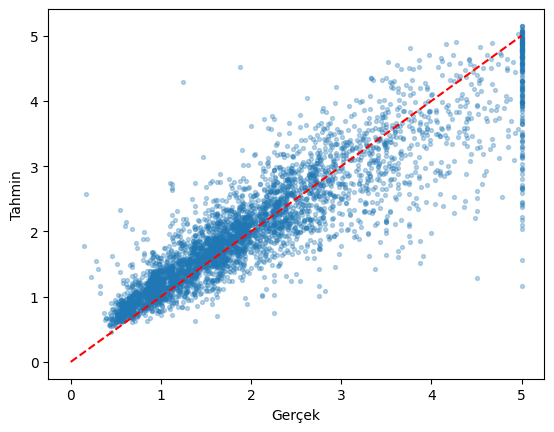

In [33]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.3, s=8)
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("Gerçek"); plt.ylabel("Tahmin")
plt.show()